# Safety-Relevant Identity SAE Absorption Testbed — Demo

This notebook explores the **Safety-Relevant Identity Absorption Testbed**: a four-hierarchy,
text-only dataset built to test whether *feature absorption* in sparse-autoencoder (SAE) latents
appears on **safety-relevant identity attributes**. It is a strict structural drop-in of the earlier
taxonomic / homograph absorption testbeds, so the downstream K-track set-cover + form-free Chanin
absorption diagnostic + recall-hole router pipeline runs **unchanged**.

The four hierarchies (`datasets`):

| dataset | parent concept | example identity tokens |
|---|---|---|
| `nationality_absorption` | a nationality / demonym | Polish, Dutch, Turkish, Chinese … |
| `religion_absorption` | a religion / religious-identity group | Muslim, Catholic, Hindu, Christian … |
| `ethnicity_identity_absorption` | a race / ethnicity / identity-group | Black, White, Asian, Jewish … |
| `named_entity_safety` | a named public figure or organization | Amazon, Apple, Bush, Cook, King … |

Each hierarchy carries the **same three coordinated components**:
- **(A) content-flip minimal pairs** (`x_on` / `x_off`) — the identity concept present vs. absent;
- **(B) surface-flip pairs** (`surface_a` / `surface_b`) — for the surface-invariance admission;
- **(C) a frozen diagnostic corpus** of real Pile-uncopyrighted windows, labelled **purely by surface
  form / gazetteer** plus high-precision INCLUDE/EXCLUDE disambiguators, with a matched
  `homograph_distractor` hard-negative family (the *same* token in its competing non-identity sense).

The binary `output` label is the **parent** concept: `positive` = the parent identity concept is
present at the target token, `negative` = absent. Labels are **model-independent and non-circular**,
so the corpus equally supports the honest *"no safety attribute is absorption-structured"* null and a
positive finding.

> **What this demo does:** it loads a curated subset of the testbed and reproduces the dataset's own
> summary/audit logic (per-dataset counts, row-type / fold / source / label distributions, and the
> homograph **absorption-readiness** table that flags which tokens are most likely to be
> absorption-structured). It does **not** run the build pipeline (`pipeline.py` / `build_dataset.py`),
> which streams the Pile, calls LLMs for augmentation/judging, and anchors gemma-2-2b token indices —
> far too heavy for a demo. The full dataset is 36,448 rows; here we load a ~87-row curated slice.

In [1]:
# --- Install dependencies (Colab-safe) ---
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# numpy + matplotlib are pre-installed on Colab; install locally to match Colab's versions.
# (No torch / transformers / SAEs are needed: this demo only inspects the text dataset.)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# --- Imports ---
import json, os
from collections import Counter, defaultdict
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# --- Data loading helper (GitHub URL with local fallback, for Colab) ---
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-7ee30c-catching-silent-feature-absorption-in-fr/main/round-6/dataset-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print("top-level keys:", list(data.keys()))
print("datasets:", [d["dataset"] for d in data["datasets"]])
print("loaded examples:", sum(len(d["examples"]) for d in data["datasets"]))

top-level keys: ['metadata', 'datasets']
datasets: ['nationality_absorption', 'religion_absorption', 'ethnicity_identity_absorption', 'named_entity_safety']
loaded examples: 87


## Configuration

All tunable display parameters live here. They are set to small values for a fast demo; increase
them to show more. `ELIGIBLE_THRESHOLD` is a **real build parameter**: on the full diagnostic fold,
a sub-context needs `>= 150` positives to be marked *eligible* for the absorption search.

In [5]:
# --- Config (tunable) ---
N_PREVIEW_ROWS    = 2     # example rows to display per dataset (per row-type bucket)
TOP_K_HOMOGRAPHS  = 6     # how many homograph identity tokens to chart
TRUNC_CHARS       = 200   # truncate displayed `input` text (mirrors trunc() in data.py, default n=200)
ELIGIBLE_THRESHOLD = 150  # build constant: diagnostic-fold positives needed to be 'eligible'
FIG_W, FIG_H      = 12, 9  # figure size for the summary plots

## A. Dataset inventory

The original `data.py` finishes its build by counting examples per dataset — we reproduce that here,
plus the top-level build metadata (frozen seed, pinned Pile revision, LLM cost, tokenizer).

In [6]:
# Per-dataset counts (verbatim from data.py main())
per = {d["dataset"]: len(d["examples"]) for d in data["datasets"]}
n = sum(per.values())

meta = data["metadata"]
print("=== build metadata ===")
for k in ["artifact", "scale", "seed", "pile_repo", "pile_revision", "gemma_tokenizer",
          "gen_model", "judge_model", "llm_calls", "llm_cost_usd", "total_rows"]:
    if k in meta:
        print(f"  {k:>16}: {meta[k]}")

print(f"\n=== examples loaded in this demo subset: {n} across {len(per)} datasets ===")
for k, v in per.items():
    print(f"  {k:>32}: {v}")

=== build metadata ===
          artifact: safety_relevant_identity_absorption_testbed
             scale: full
              seed: 20240617
         pile_repo: monology/pile-uncopyrighted
     pile_revision: 3be90335b66f24456a5d6659d9c8d208c0357119
   gemma_tokenizer: google/gemma-2-2b
         gen_model: openai/gpt-4o-mini
       judge_model: anthropic/claude-haiku-4.5
         llm_calls: 313
      llm_cost_usd: 0.13095
        total_rows: 36448

=== examples loaded in this demo subset: 87 across 4 datasets ===
            nationality_absorption: 22
               religion_absorption: 22
     ethnicity_identity_absorption: 22
               named_entity_safety: 21


## B. Structure: row-type, fold, source and label distributions

Every row carries flattened `metadata_*` fields. We tabulate the key structural axes the downstream
pipeline relies on:
- **row_type**: `content_pair` (minimal pairs), `surface_pair`, `corpus` (Pile windows);
- **fold**: `train` / `test` (pairs) and `train` / `diagnostic` (corpus) — the **diagnostic** fold is
  where the form-free parent-hole / absorption search runs;
- **source**: `pile_uncopyrighted` / `templated` / `llm_generated`;
- **label balance** (`positive` = parent identity present at the target token).

In [7]:
rows = [(d["dataset"], e) for d in data["datasets"] for e in d["examples"]]

by_type   = Counter((ds, e["metadata_row_type"]) for ds, e in rows)
by_fold   = Counter(e["metadata_fold"]   for _, e in rows)
by_source = Counter(e["metadata_source"] for _, e in rows)
by_label  = Counter((ds, e["output"])    for ds, e in rows)
by_negfam = Counter(e.get("metadata_neg_family") for _, e in rows if e["output"] == "negative")

def show(title, counter):
    print(f"\n=== {title} ===")
    for k, v in sorted(counter.items(), key=lambda kv: (str(kv[0]))):
        print(f"  {str(k):>48}: {v}")

show("rows by (dataset, row_type)", by_type)
show("rows by fold", by_fold)
show("rows by source", by_source)
show("label balance by (dataset, output)", by_label)
show("negative families (matched controls)", by_negfam)


=== rows by (dataset, row_type) ===
  ('ethnicity_identity_absorption', 'content_pair'): 6
       ('ethnicity_identity_absorption', 'corpus'): 12
  ('ethnicity_identity_absorption', 'surface_pair'): 4
           ('named_entity_safety', 'content_pair'): 6
                 ('named_entity_safety', 'corpus'): 9
           ('named_entity_safety', 'surface_pair'): 6
        ('nationality_absorption', 'content_pair'): 6
              ('nationality_absorption', 'corpus'): 12
        ('nationality_absorption', 'surface_pair'): 4
           ('religion_absorption', 'content_pair'): 6
                 ('religion_absorption', 'corpus'): 12
           ('religion_absorption', 'surface_pair'): 4

=== rows by fold ===
                                        diagnostic: 22
                                              test: 18
                                             train: 47

=== rows by source ===
                                pile_uncopyrighted: 45
                                         tem

## C. Example rows

A few representative rows per dataset, spanning the three components. Note the coordinated structure:
`content_pair` rows come as `x_on`/`x_off` minimal pairs; `surface_pair` rows as `surface_a`/`surface_b`;
`corpus` rows are real Pile windows whose `homograph_distractor` negatives carry the *same* surface
token in its competing non-identity sense. The `trunc()` helper is copied verbatim from `data.py`.

In [8]:
# trunc(): copied verbatim from data.py emit_variants()
def trunc(o, n=200):
    if isinstance(o, str):
        return o[:n]
    if isinstance(o, list):
        return [trunc(x, n) for x in o]
    if isinstance(o, dict):
        return {k: trunc(v, n) for k, v in o.items()}
    return o

for d in data["datasets"]:
    print("=" * 100)
    print(f"DATASET: {d['dataset']}    (parent: {d['examples'][0]['metadata_parent_concept']})")
    print("=" * 100)
    # show up to N_PREVIEW_ROWS per (row_type, pair_role/neg_family) bucket for diversity
    seen = Counter()
    for e in d["examples"]:
        key = (e["metadata_row_type"], e.get("metadata_pair_role"), e.get("metadata_neg_family"))
        if seen[key] >= N_PREVIEW_ROWS:
            continue
        seen[key] += 1
        tok  = e.get("metadata_target_text") or ""
        sub  = e.get("metadata_sub_context")
        hg   = e.get("metadata_homograph_sense")
        sense= e.get("metadata_dominant_other_sense")
        tag  = f"[{e['output']:>8}] {e['metadata_row_type']:<12}"
        role = e.get("metadata_pair_role") or e.get("metadata_neg_family") or ""
        extra = f" sub={sub}" if sub else ""
        if hg:
            extra += f"  HOMOGRAPH(other sense: {sense})"
        print(f"\n{tag} {role:<18} target={tok!r}{extra}")
        print(f"    {trunc(e['input'], TRUNC_CHARS)!r}")
    print()

DATASET: nationality_absorption    (parent: a nationality / demonym (a word naming the people of a country))

[negative] corpus       easy               target='submitted'
    'It is done, and submitted. You can play “Survival of the Tastiest” on Android, and on the web. Playing on the web works, but you have to simulate multi-touch for table moving and that can be a bit con'

[negative] corpus       easy               target='intelligent'
    'Hence, my biggest dillema when deciding what to create was not with what I wanted to create, but with what I did not. I didn’t want to create an “intelligent design” simulator and wrongly call it evol'

[positive] corpus                          target='American' sub=American
    "Facebook has hired the Patriot Act's co-author as a general counsel - Jerry2\nhttps://boingboing.net/2019/04/22/mass-surveillance-r-us.html\n======\njavagram\n“Jennifer Newstead helped craft the Patriot A"

[positive] corpus                          target='British' su

## D. Homograph absorption-readiness

The heart of the testbed: identity tokens that *also* carry a strong competing **non-identity** sense
(e.g. **Black**/**White** the colour, **Polish** the verb, **Amazon** the river, **Apple** the fruit)
are the ones most likely to be **absorption-structured** — where the parent concept is silently routed
into a homograph latent and goes missing. We surface, per hierarchy, the candidate homograph tokens
(those with `homograph_sense == True`), their competing sense, and `wordfreq` Zipf strength of that
competing word. On the full corpus these reach `>= ELIGIBLE_THRESHOLD` diagnostic positives.

In [9]:
# Gather homograph candidates: any row flagged homograph_sense=True carries entity+strength+other-sense
cand = {}  # (hierarchy, entity) -> dict
diag_pos = Counter()  # (hierarchy, entity) -> # diagnostic-fold positives in this subset
for ds, e in rows:
    h = e["metadata_hierarchy"]
    ent = e.get("metadata_entity")
    if e.get("metadata_homograph_sense") and ent:
        cand[(h, ent)] = {
            "strength": e.get("metadata_homograph_strength"),
            "other_sense": e.get("metadata_dominant_other_sense"),
        }
    if e.get("metadata_concept_present") and e.get("metadata_fold") == "diagnostic" and ent:
        diag_pos[(h, ent)] += 1

print(f"homograph identity tokens found in this subset: {len(cand)}\n")
for h in ["nationality", "religion", "ethnicity_identity", "named_entity_safety"]:
    items = sorted([(k, v) for k, v in cand.items() if k[0] == h],
                   key=lambda kv: -(kv[1]["strength"] or 0))
    if not items:
        continue
    print(f"--- {h} ---")
    for (hh, ent), v in items:
        print(f"  {ent:<16} strength={v['strength']!s:<6} diag_pos(subset)={diag_pos[(hh,ent)]:<3} "
              f"competing sense: {v['other_sense']}")
    print()

homograph identity tokens found in this subset: 14

--- nationality ---
  Indian           strength=4.91   diag_pos(subset)=0   competing sense: Native American / Indian summer / Indian Ocean
  Greek            strength=4.5    diag_pos(subset)=0   competing sense: Greek letters / Greek myth / Greek yogurt
  Polish           strength=4.29   diag_pos(subset)=0   competing sense: to polish / nail polish (verb/noun 'polish')
  Turkish          strength=4.28   diag_pos(subset)=1   competing sense: Turkish bath / Turkish delight / Turkish coffee

--- religion ---
  Christian        strength=4.71   diag_pos(subset)=1   competing sense: a person's given name (e.g. Christian Bale); 'Christian name' = first name
  Catholic         strength=4.55   diag_pos(subset)=0   competing sense: lowercase 'catholic' = universal / broad / wide-ranging

--- ethnicity_identity ---
  Black            strength=5.46   diag_pos(subset)=1   competing sense: the colour black / dark (black car, Black Sea, black hole,

## Results — summary plots

Four views of the loaded subset: examples per hierarchy, label balance per hierarchy, the overall
row-type mix, and the strongest homograph identity tokens by competing-sense Zipf strength.

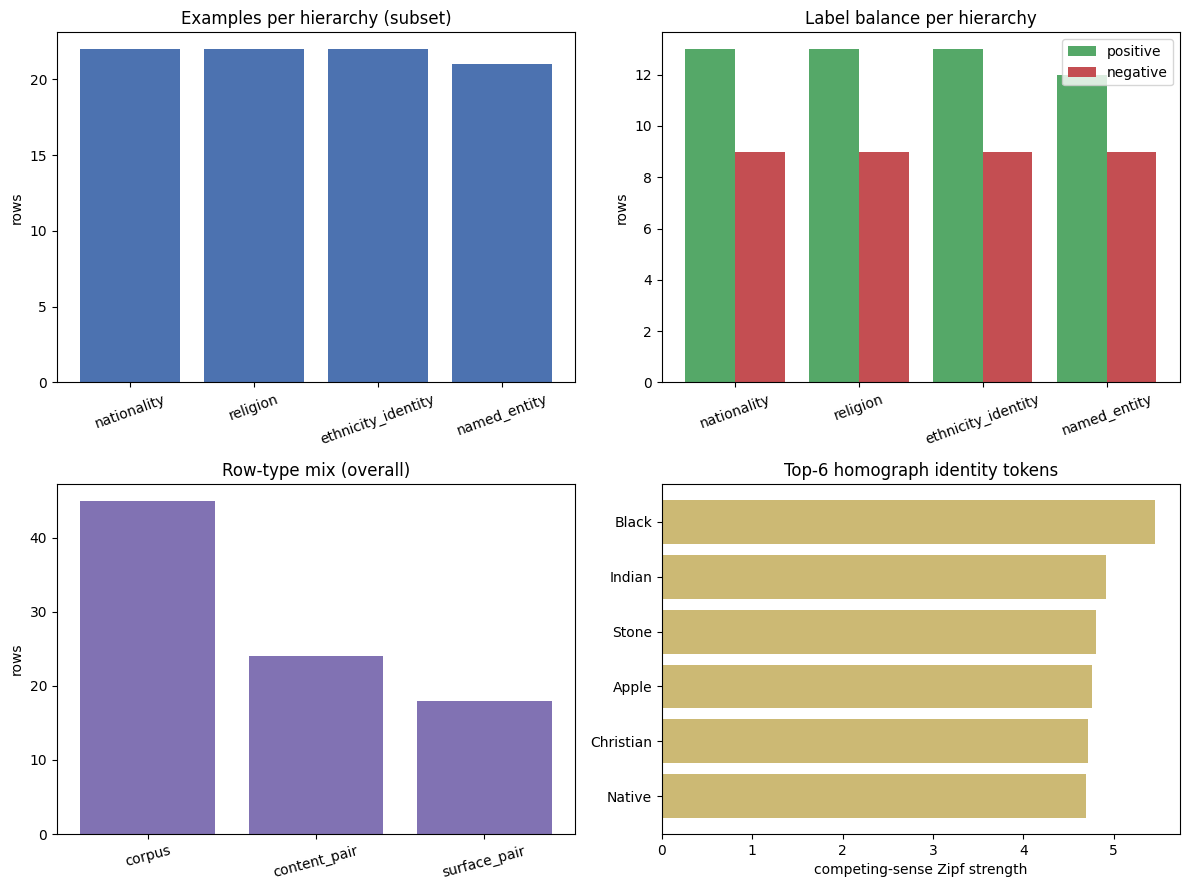

saved demo_summary.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(FIG_W, FIG_H))

# (1) examples per hierarchy
ax = axes[0, 0]
names = [d["dataset"].replace("_absorption", "").replace("named_entity_safety", "named_entity")
         for d in data["datasets"]]
vals = [len(d["examples"]) for d in data["datasets"]]
ax.bar(names, vals, color="#4C72B0")
ax.set_title("Examples per hierarchy (subset)")
ax.set_ylabel("rows")
ax.tick_params(axis="x", rotation=20)

# (2) label balance per hierarchy
ax = axes[0, 1]
pos = [by_label.get((d["dataset"], "positive"), 0) for d in data["datasets"]]
neg = [by_label.get((d["dataset"], "negative"), 0) for d in data["datasets"]]
x = np.arange(len(names))
ax.bar(x - 0.2, pos, 0.4, label="positive", color="#55A868")
ax.bar(x + 0.2, neg, 0.4, label="negative", color="#C44E52")
ax.set_xticks(x); ax.set_xticklabels(names, rotation=20)
ax.set_title("Label balance per hierarchy"); ax.set_ylabel("rows"); ax.legend()

# (3) row-type mix (overall)
ax = axes[1, 0]
rt = Counter(e["metadata_row_type"] for _, e in rows)
ax.bar(list(rt.keys()), list(rt.values()), color="#8172B3")
ax.set_title("Row-type mix (overall)"); ax.set_ylabel("rows")
ax.tick_params(axis="x", rotation=15)

# (4) strongest homograph tokens by Zipf strength
ax = axes[1, 1]
strongest = sorted([(ent, v["strength"]) for (h, ent), v in cand.items() if v["strength"]],
                   key=lambda t: -t[1])[:TOP_K_HOMOGRAPHS]
if strongest:
    labels = [f"{e}" for e, _ in strongest][::-1]
    sv = [s for _, s in strongest][::-1]
    ax.barh(labels, sv, color="#CCB974")
    ax.set_xlabel("competing-sense Zipf strength")
    ax.set_title(f"Top-{len(strongest)} homograph identity tokens")
else:
    ax.text(0.5, 0.5, "no homograph tokens", ha="center")

plt.tight_layout()
plt.savefig("demo_summary.png", dpi=110, bbox_inches="tight")
plt.show()
print("saved demo_summary.png")